In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits


## Loading

In [2]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

native_edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion/v2/runs/all/edm4hep.root"
native_batch = EDM4hepEventBatch(native_edm_input_file, events=(0, 100), full_load=False, detector_params=detector_params)

acts_edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion/v1/runs/all/edm4hep.root"
acts_batch = EDM4hepEventBatch(acts_edm_input_file, events=(0, 100), full_load=False, detector_params=detector_params)

In [3]:
acts_hits = acts_batch.get_tracker_hits_df()
acts_particles = acts_batch.get_particles_df()

native_hits = native_batch.get_tracker_hits_df()
native_particles = native_batch.get_particles_df()


Augmenting particle hit counts with tracker hits
Augmenting particle hit counts with tracker hits


## Statistics Comparison


In [4]:
print("=" * 80)
print("NATIVE SIMULATION STATISTICS")
print("=" * 80)
print(f"\nHits:")
print(f"  Total hits: {len(native_hits)}")
print(f"  Hits per event: {native_hits.groupby('event_id').size().describe()}")
print(f"\nParticles:")
print(f"  Total particles: {len(native_particles)}")
print(f"  Particles per event: {native_particles.groupby('event_id').size().describe()}")
print(f"  Particles created in simulation: {native_particles['created_in_simulation'].sum()}")
print(f"  Particles created inside tracker: {native_particles['created_inside_tracker'].sum()}")

print("\n" + "=" * 80)
print("ACTS SIMULATION STATISTICS")
print("=" * 80)
print(f"\nHits:")
print(f"  Total hits: {len(acts_hits)}")
print(f"  Hits per event: {acts_hits.groupby('event_id').size().describe()}")
print(f"\nParticles:")
print(f"  Total particles: {len(acts_particles)}")
print(f"  Particles per event: {acts_particles.groupby('event_id').size().describe()}")
print(f"  Particles created in simulation: {acts_particles['created_in_simulation'].sum()}")
if 'created_inside_tracker' in acts_particles.columns:
    print(f"  Particles created inside tracker: {acts_particles['created_inside_tracker'].sum()}")


NATIVE SIMULATION STATISTICS

Hits:
  Total hits: 5852
  Hits per event: count    100.000000
mean      58.520000
std       69.476612
min        6.000000
25%       17.750000
50%       31.000000
75%       72.250000
max      449.000000
dtype: float64

Particles:
  Total particles: 124647
  Particles per event: count     100.000000
mean     1246.470000
std       882.036847
min         1.000000
25%       507.000000
50%      1230.500000
75%      1838.000000
max      3521.000000
dtype: float64
  Particles created in simulation: 124547
  Particles created inside tracker: 2589

ACTS SIMULATION STATISTICS

Hits:
  Total hits: 6362
  Hits per event: count    100.000000
mean      63.620000
std      107.545694
min        6.000000
25%       15.750000
50%       24.000000
75%       57.250000
max      641.000000
dtype: float64

Particles:
  Total particles: 731984
  Particles per event: count      100.000000
mean      7319.840000
std       6086.039451
min          2.000000
25%       3100.500000
50%    

In [5]:
# Comparison summary
print("=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)
print(f"\nHits difference:")
print(f"  Native: {len(native_hits)}, ACTS: {len(acts_hits)}, Diff: {len(native_hits) - len(acts_hits)}")
print(f"  Ratio (Native/ACTS): {len(native_hits) / len(acts_hits):.2f}")

print(f"\nParticles difference:")
print(f"  Native: {len(native_particles)}, ACTS: {len(acts_particles)}, Diff: {len(native_particles) - len(acts_particles)}")
print(f"  Ratio (Native/ACTS): {len(native_particles) / len(acts_particles):.2f}")

print(f"\nParticles created in simulation:")
print(f"  Native: {native_particles['created_in_simulation'].sum()}, ACTS: {acts_particles['created_in_simulation'].sum()}")
print(f"  Diff: {native_particles['created_in_simulation'].sum() - acts_particles['created_in_simulation'].sum()}")


COMPARISON SUMMARY

Hits difference:
  Native: 5852, ACTS: 6362, Diff: -510
  Ratio (Native/ACTS): 0.92

Particles difference:
  Native: 124647, ACTS: 731984, Diff: -607337
  Ratio (Native/ACTS): 0.17

Particles created in simulation:
  Native: 124547, ACTS: 731784
  Diff: -607237


## Comparison Plots


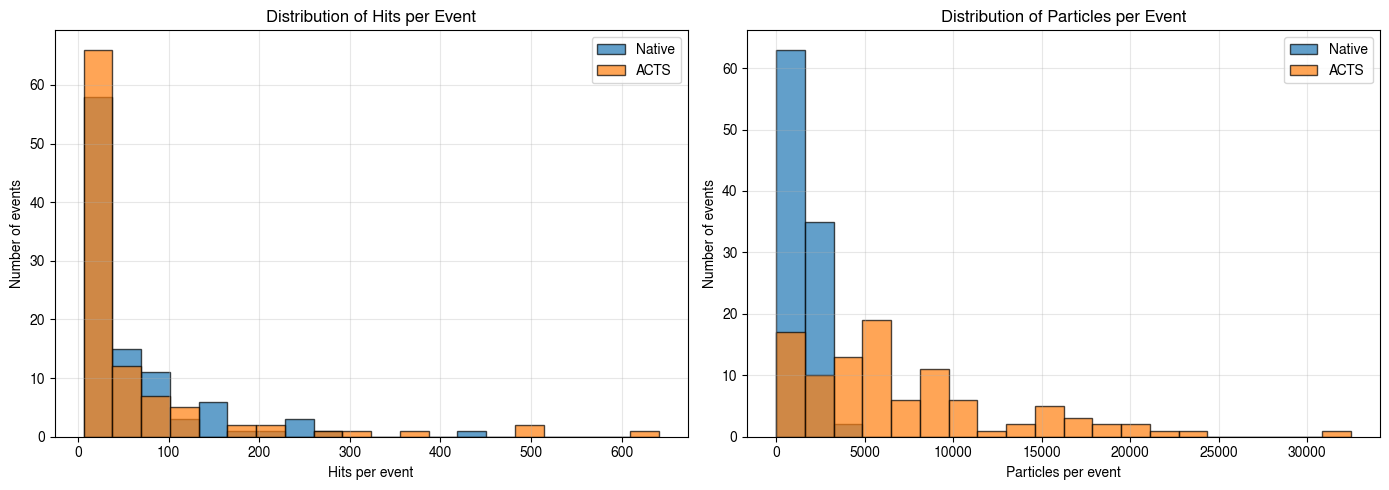

In [6]:
# Plot 1: Number of hits per event
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

native_hits_per_event = native_hits.groupby('event_id').size()
acts_hits_per_event = acts_hits.groupby('event_id').size()

# Determine common bins for hits per event
hits_min = min(native_hits_per_event.min(), acts_hits_per_event.min())
hits_max = max(native_hits_per_event.max(), acts_hits_per_event.max())
hits_bins = np.linspace(hits_min, hits_max, 21)

axes[0].hist(native_hits_per_event, bins=hits_bins, alpha=0.7, label='Native', edgecolor='black')
axes[0].hist(acts_hits_per_event, bins=hits_bins, alpha=0.7, label='ACTS', edgecolor='black')
axes[0].set_xlabel('Hits per event')
axes[0].set_ylabel('Number of events')
axes[0].set_title('Distribution of Hits per Event')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Particles per event
native_particles_per_event = native_particles.groupby('event_id').size()
acts_particles_per_event = acts_particles.groupby('event_id').size()

# Determine common bins for particles per event
particles_min = min(native_particles_per_event.min(), acts_particles_per_event.min())
particles_max = max(native_particles_per_event.max(), acts_particles_per_event.max())
particles_bins = np.linspace(particles_min, particles_max, 21)

axes[1].hist(native_particles_per_event, bins=particles_bins, alpha=0.7, label='Native', edgecolor='black')
axes[1].hist(acts_particles_per_event, bins=particles_bins, alpha=0.7, label='ACTS', edgecolor='black')
axes[1].set_xlabel('Particles per event')
axes[1].set_ylabel('Number of events')
axes[1].set_title('Distribution of Particles per Event')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


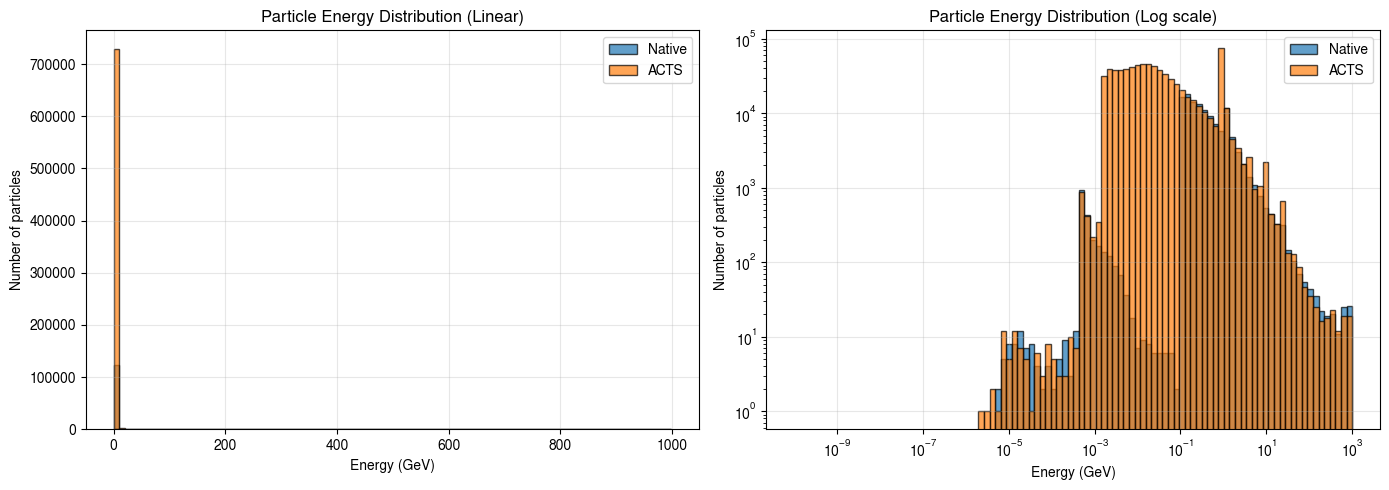

In [7]:
# Plot 2: Energy distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Determine common bins for energy
energy_min = min(native_particles['energy'].min(), acts_particles['energy'].min())
energy_max = max(native_particles['energy'].max(), acts_particles['energy'].max())
energy_bins = np.linspace(energy_min, energy_max, 101)

axes[0].hist(native_particles['energy'], bins=energy_bins, alpha=0.7, label='Native', edgecolor='black')
axes[0].hist(acts_particles['energy'], bins=energy_bins, alpha=0.7, label='ACTS', edgecolor='black')
axes[0].set_xlabel('Energy (GeV)')
axes[0].set_ylabel('Number of particles')
axes[0].set_title('Particle Energy Distribution (Linear)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# For log scale, use log-spaced bins
energy_log_bins = np.logspace(np.log10(max(energy_min, 1e-10)), np.log10(energy_max), 101)

axes[1].hist(native_particles['energy'], bins=energy_log_bins, alpha=0.7, label='Native', edgecolor='black')
axes[1].hist(acts_particles['energy'], bins=energy_log_bins, alpha=0.7, label='ACTS', edgecolor='black')
axes[1].set_xlabel('Energy (GeV)')
axes[1].set_ylabel('Number of particles')
axes[1].set_title('Particle Energy Distribution (Log scale)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


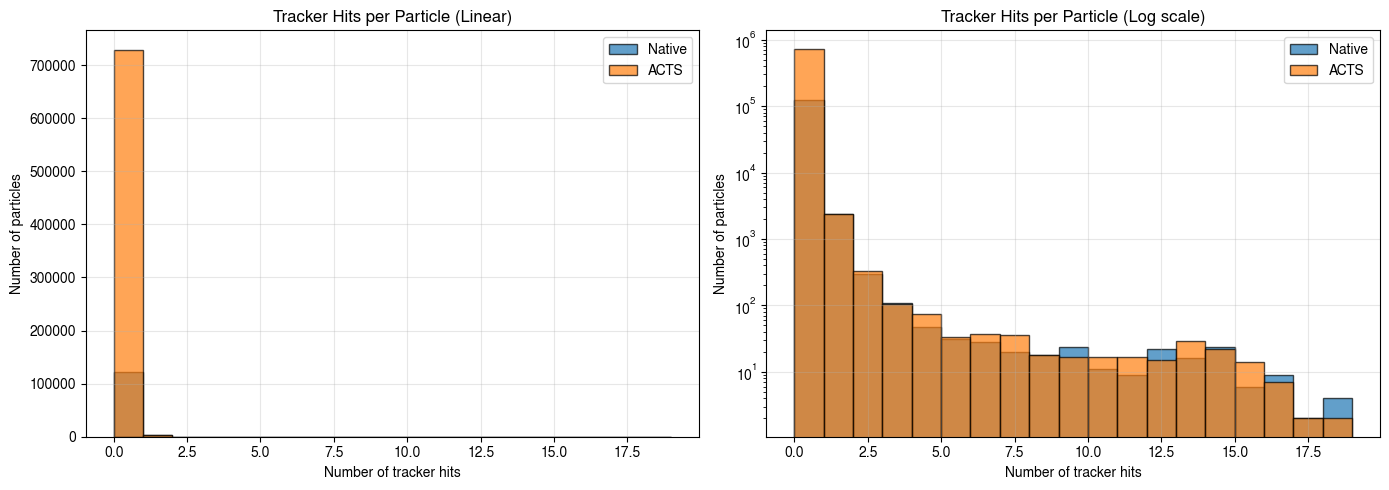

In [8]:
# Plot 3: Number of tracker hits per particle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(native_particles['num_tracker_hits'], bins=range(0, 20), alpha=0.7, label='Native', edgecolor='black')
axes[0].hist(acts_particles['num_tracker_hits'], bins=range(0, 20), alpha=0.7, label='ACTS', edgecolor='black')
axes[0].set_xlabel('Number of tracker hits')
axes[0].set_ylabel('Number of particles')
axes[0].set_title('Tracker Hits per Particle (Linear)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(native_particles['num_tracker_hits'], bins=range(0, 20), alpha=0.7, label='Native', edgecolor='black')
axes[1].hist(acts_particles['num_tracker_hits'], bins=range(0, 20), alpha=0.7, label='ACTS', edgecolor='black')
axes[1].set_xlabel('Number of tracker hits')
axes[1].set_ylabel('Number of particles')
axes[1].set_title('Tracker Hits per Particle (Log scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
native_particles.columns

Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
       'created_in_simulation', 'num_tracker_hits', 'num_calo_hits',
       'created_inside_tracker'],
      dtype='object')

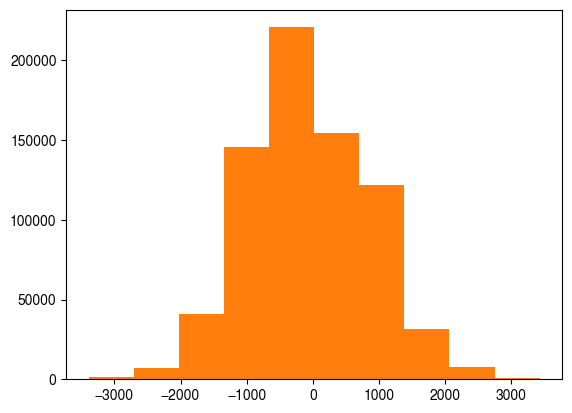

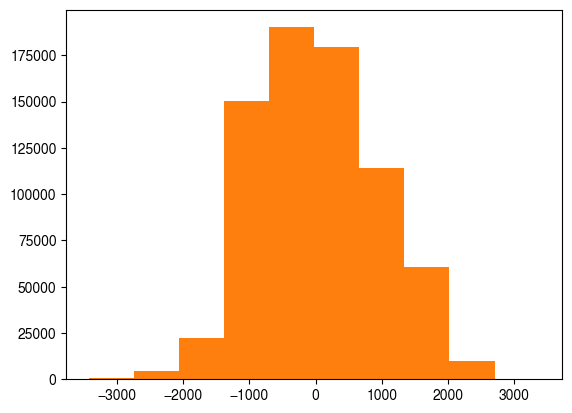

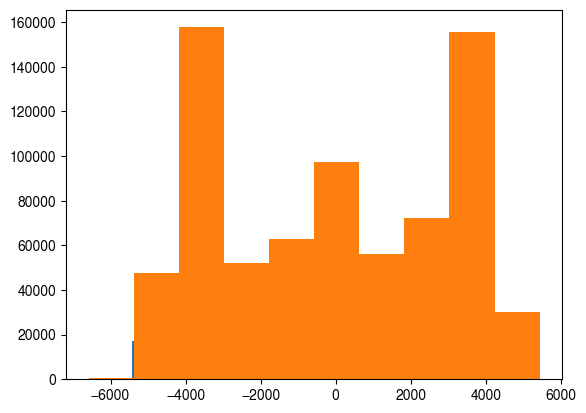

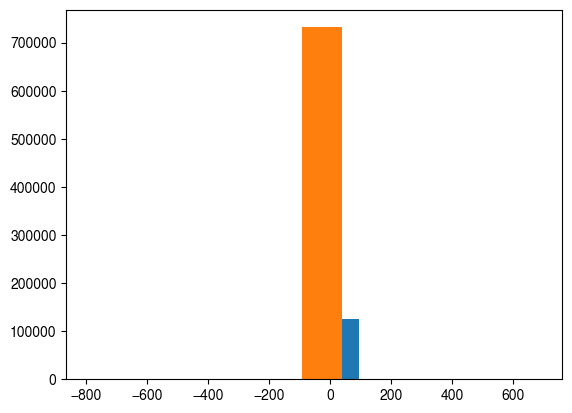

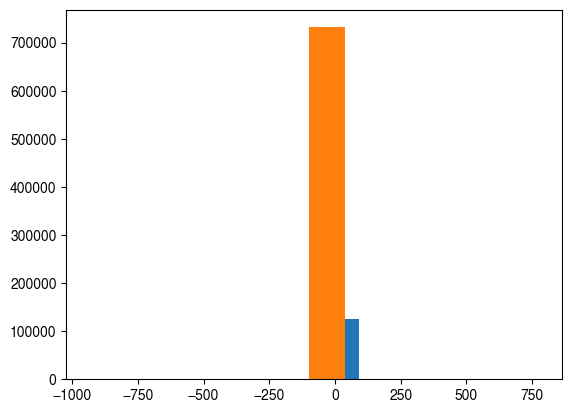

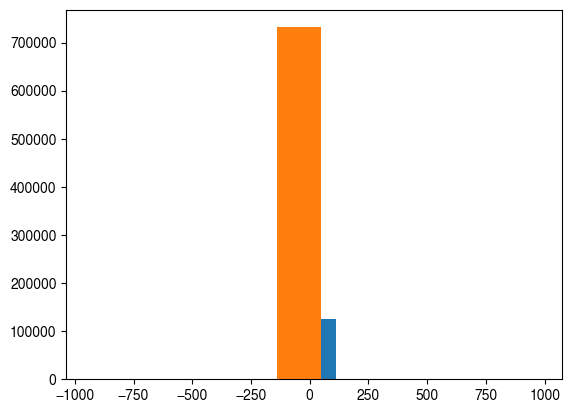

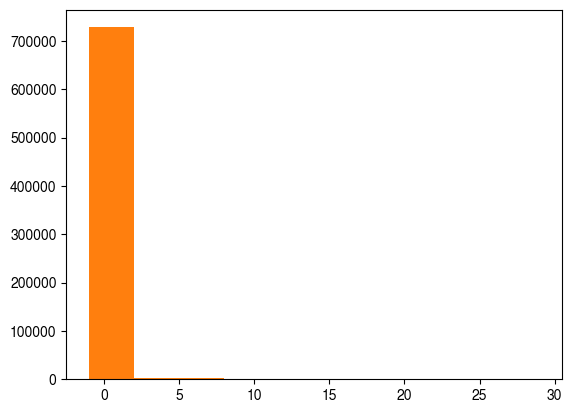

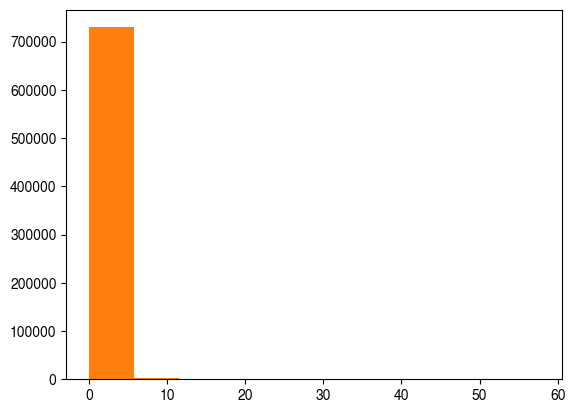

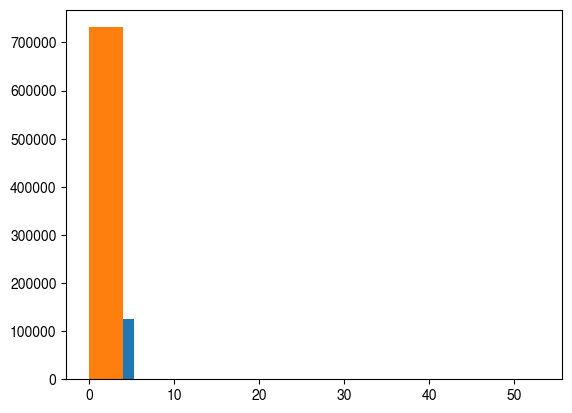

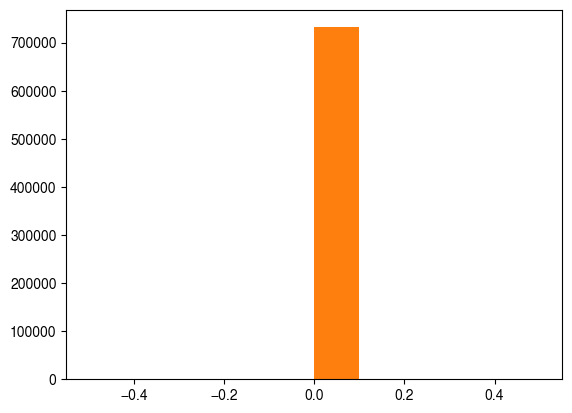

In [10]:
# 'event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
#        'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
#        'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
#        'created_in_simulation', 'num_tracker_hits', 'num_calo_hits',
#        'created_inside_tracker'],

for col in ['vx', 'vy', 'vz', 'px', 'py', 'pz', 'charge', 'mass', 'num_tracker_hits', 'num_calo_hits']:
    plt.hist(native_particles[col])
    plt.hist(acts_particles[col])
    plt.show()

## ACTS Simulation Detailed Analysis


In [28]:
# Question 6: How many particles per event are created in simulation?
particles_created_in_sim_per_event = acts_particles[acts_particles['created_in_simulation'] == True].groupby('event_id').size()

print("=" * 80)
print("PARTICLES CREATED IN SIMULATION (ACTS)")
print("=" * 80)
print(f"\nStatistics per event:")
print(particles_created_in_sim_per_event.describe())
print(f"\nMean particles created in simulation per event: {particles_created_in_sim_per_event.mean():.2f}")
print(f"Median particles created in simulation per event: {particles_created_in_sim_per_event.median():.2f}")
print(f"\nBreakdown per event:")
for event_id, count in particles_created_in_sim_per_event.items():
    print(f"  Event {event_id}: {count} particles")


PARTICLES CREATED IN SIMULATION (ACTS)

Statistics per event:
count       97.000000
mean      7544.164948
std       6039.217981
min          1.000000
25%       3377.000000
50%       6013.000000
75%       9650.000000
max      32492.000000
dtype: float64

Mean particles created in simulation per event: 7544.16
Median particles created in simulation per event: 6013.00

Breakdown per event:
  Event 0: 1377 particles
  Event 1: 1184 particles
  Event 2: 1985 particles
  Event 3: 928 particles
  Event 4: 2944 particles
  Event 5: 4509 particles
  Event 6: 5450 particles
  Event 7: 6539 particles
  Event 8: 5651 particles
  Event 9: 742 particles
  Event 10: 1563 particles
  Event 11: 1 particles
  Event 12: 4174 particles
  Event 13: 9233 particles
  Event 14: 4333 particles
  Event 15: 5504 particles
  Event 16: 5712 particles
  Event 17: 17401 particles
  Event 18: 14248 particles
  Event 19: 4836 particles
  Event 20: 974 particles
  Event 21: 9424 particles
  Event 23: 15332 particles
  

In [29]:
# Question 7: How many particles per event are created in the tracker?
if 'created_inside_tracker' in acts_particles.columns:
    particles_created_in_tracker_per_event = acts_particles[acts_particles['created_inside_tracker'] == True].groupby('event_id').size()
    
    print("=" * 80)
    print("PARTICLES CREATED IN TRACKER (ACTS)")
    print("=" * 80)
    print(f"\nStatistics per event:")
    print(particles_created_in_tracker_per_event.describe())
    print(f"\nMean particles created in tracker per event: {particles_created_in_tracker_per_event.mean():.2f}")
    print(f"Median particles created in tracker per event: {particles_created_in_tracker_per_event.median():.2f}")
    print(f"\nBreakdown per event:")
    for event_id, count in particles_created_in_tracker_per_event.items():
        print(f"  Event {event_id}: {count} particles")
else:
    print("Column 'created_inside_tracker' not found in ACTS particles dataframe")


PARTICLES CREATED IN TRACKER (ACTS)

Statistics per event:
count     100.000000
mean       63.520000
std       185.388017
min         2.000000
25%         4.750000
50%        13.000000
75%        50.000000
max      1647.000000
dtype: float64

Mean particles created in tracker per event: 63.52
Median particles created in tracker per event: 13.00

Breakdown per event:
  Event 0: 102 particles
  Event 1: 21 particles
  Event 2: 17 particles
  Event 3: 108 particles
  Event 4: 9 particles
  Event 5: 66 particles
  Event 6: 17 particles
  Event 7: 7 particles
  Event 8: 6 particles
  Event 9: 4 particles
  Event 10: 26 particles
  Event 11: 3 particles
  Event 12: 4 particles
  Event 13: 9 particles
  Event 14: 62 particles
  Event 15: 6 particles
  Event 16: 2 particles
  Event 17: 250 particles
  Event 18: 32 particles
  Event 19: 4 particles
  Event 20: 10 particles
  Event 21: 42 particles
  Event 22: 2 particles
  Event 23: 25 particles
  Event 24: 10 particles
  Event 25: 175 particle

In [30]:
# Question 8: How many events have the primary particle not reaching the calo?
# Primary particles are those NOT created in simulation
primary_particles = acts_particles[acts_particles['created_in_simulation'] == False]

print("=" * 80)
print("PRIMARY PARTICLE CALO ANALYSIS (ACTS)")
print("=" * 80)

# For each event, check if the primary particle reached the calo
events_with_primary_no_calo = []
total_events = len(primary_particles['event_id'].unique())

for event_id in primary_particles['event_id'].unique():
    event_primary = primary_particles[primary_particles['event_id'] == event_id]
    # Check if any primary particle in this event has calo hits
    has_calo_hits = (event_primary['num_calo_hits'] > 0).any()
    if not has_calo_hits:
        events_with_primary_no_calo.append(event_id)

num_events_no_calo = len(events_with_primary_no_calo)
fraction_no_calo = num_events_no_calo / total_events if total_events > 0 else 0

print(f"\nTotal events with primary particles: {total_events}")
print(f"Events where primary particle(s) did NOT reach calo: {num_events_no_calo}")
print(f"Fraction of events with no calo hits from primary: {fraction_no_calo:.2%}")
print(f"Average: {fraction_no_calo:.2%} of events have primary particles not reaching the calo")

if events_with_primary_no_calo:
    print(f"\nEvent IDs where primary did not reach calo: {events_with_primary_no_calo}")


PRIMARY PARTICLE CALO ANALYSIS (ACTS)

Total events with primary particles: 100
Events where primary particle(s) did NOT reach calo: 100
Fraction of events with no calo hits from primary: 100.00%
Average: 100.00% of events have primary particles not reaching the calo

Event IDs where primary did not reach calo: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(4

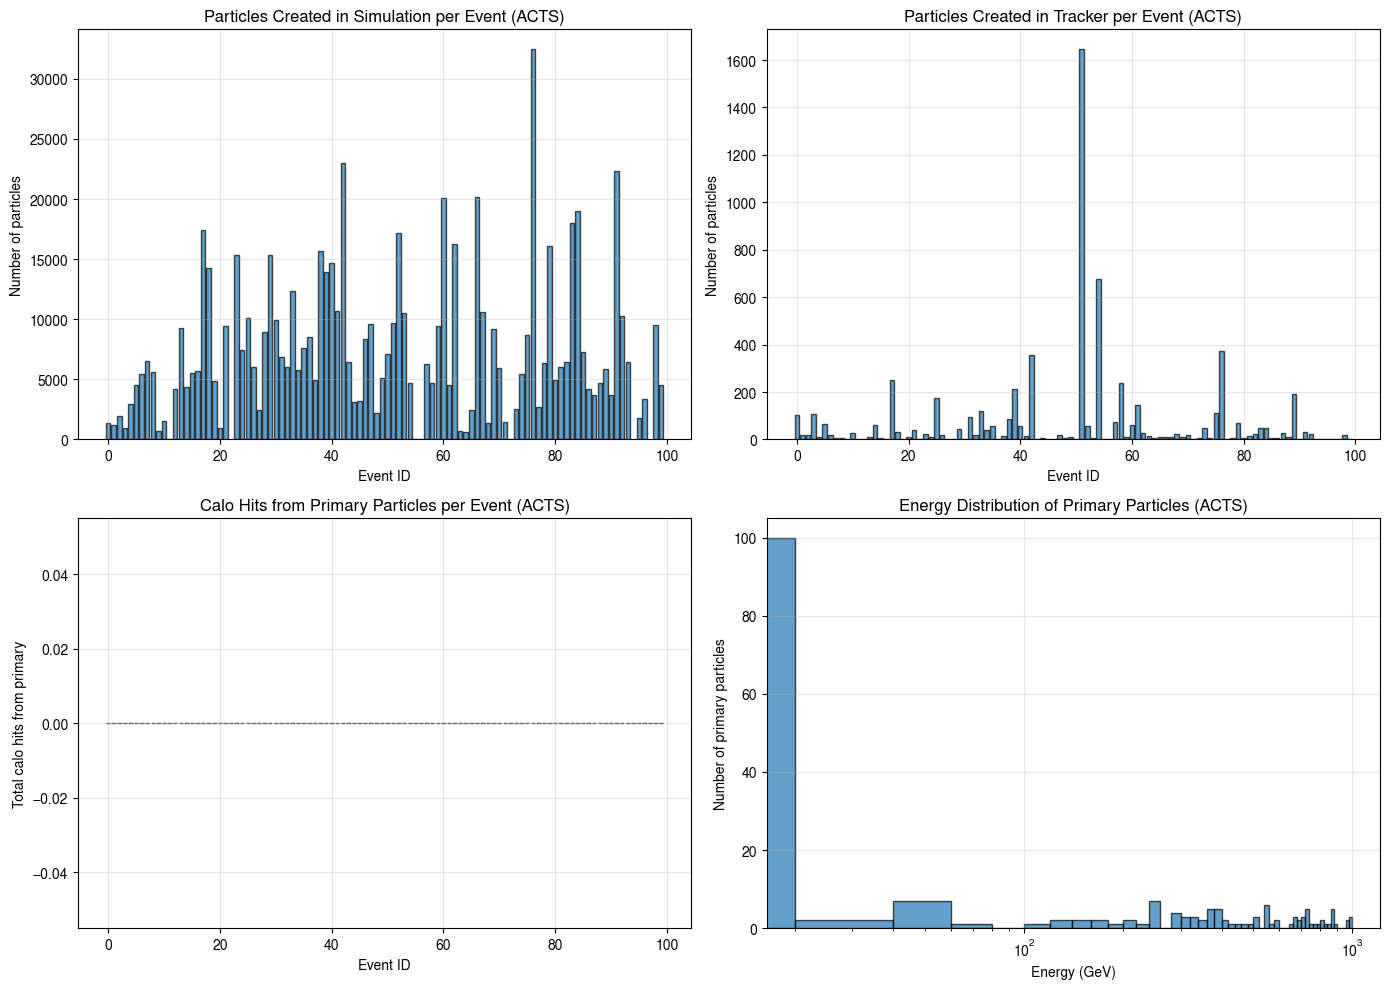

In [31]:
# Additional visualization for ACTS analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Particles created in simulation per event
axes[0, 0].bar(particles_created_in_sim_per_event.index, particles_created_in_sim_per_event.values, 
               edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Event ID')
axes[0, 0].set_ylabel('Number of particles')
axes[0, 0].set_title('Particles Created in Simulation per Event (ACTS)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Particles created in tracker per event
if 'created_inside_tracker' in acts_particles.columns:
    axes[0, 1].bar(particles_created_in_tracker_per_event.index, particles_created_in_tracker_per_event.values,
                   edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Event ID')
    axes[0, 1].set_ylabel('Number of particles')
    axes[0, 1].set_title('Particles Created in Tracker per Event (ACTS)')
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Particles Created in Tracker per Event (ACTS)')

# Plot 3: Primary particles calo hits
primary_calo_hits = primary_particles.groupby('event_id')['num_calo_hits'].sum()
axes[1, 0].bar(primary_calo_hits.index, primary_calo_hits.values, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Event ID')
axes[1, 0].set_ylabel('Total calo hits from primary')
axes[1, 0].set_title('Calo Hits from Primary Particles per Event (ACTS)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Distribution of primary particle energies
axes[1, 1].hist(primary_particles['energy'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Energy (GeV)')
axes[1, 1].set_ylabel('Number of primary particles')
axes[1, 1].set_title('Energy Distribution of Primary Particles (ACTS)')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

This notebook compares ACTS and Native simulations for single particle (pion) events:

1. Loaded both ACTS (v1) and Native (v2) simulation data
2. Printed detailed statistics for hits and particles in both simulations
3. Compared key metrics between the two simulations
4. Created comparison plots for:
   - Hits and particles per event distributions
   - Energy distributions
   - Tracker hits per particle
5. Analyzed ACTS simulation in detail:
   - Particles created in simulation per event
   - Particles created in tracker per event
   - Events where primary particles did not reach the calorimeter
